In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
states = ['H', 'V', 'I']
P = np.array([
    [0.994266, 0.000000, 0.005734],
    [0.129032, 0.838710, 0.032258],
    [0.000000, 0.116279, 0.883721]
])

print("Row sums: ", P.sum(axis=1))

Row sums:  [1. 1. 1.]


In [3]:
N = 10000
n_games = 82

total_injured = np.zeros(N)
total_episodes = np.zeros(N)
recovery_times = []

for i in range(N):
    current = 0
    trajectory = [current]

    # simulate one season
    for game in range(n_games - 1):
        current = np.random.choice([0, 1, 2], p=P[current, :])
        trajectory.append(current)
        
    trajectory = np.array(trajectory)

    # count games spent injured
    total_injured[i] = np.sum(trajectory == 2)

    # count injury episodes (separate periods spent in I)
    episodes = 0
    for j in range(1, len(trajectory)):
        if trajectory[j] == 2 and trajectory[j-1] != 2:
            episodes += 1
    total_episodes[i] = episodes

    # track recovery times (how many games from entering I to reaching H)
    injured = False
    injury_start = 0
    for j in range(len(trajectory)):
        if trajectory[j] == 2 and not injured:
            injured = True
            injury_start = j
        elif trajectory[j] == 0 and injured:
            recovery_times.append(j - injury_start)
            injured = False

In [9]:
mu_I = np.mean(total_injured)
err_I = np.std(total_injured) / np.sqrt(N)

mu_ep = np.mean(total_episodes)
err_ep = np.std(total_episodes) / np.sqrt(N)

print(f"Average games injured per season: {mu_I:.3f} +/- {err_I:.3f}")
print(f"Average injury episodes per season: {mu_ep:.3f} +/- {err_ep:.3f}")

Average games injured per season: 3.974 +/- 0.078
Average injury episodes per season: 0.506 +/- 0.008


In [10]:
p_none = np.mean(total_episodes == 0)
p_any = np.mean(total_episodes >= 1)
p_two_plus = np.mean(total_episodes >= 2)

err_none = np.std(total_episodes == 0) / np.sqrt(N)
err_any = np.std(total_episodes >= 1) / np.sqrt(N)
err_two = np.std(total_episodes >= 2) / np.sqrt(N)

print(f"P(injury-free season) = {p_none:.3f} +/- {err_none:.3f}")
print(f"P(at least 1 injury episode) = {p_any:.3f} +/- {err_any:.3f}")
print(f"P(at least 2 injury episodes) = {p_two_plus:.3f} +/- {err_two:.3f}")

P(injury-free season) = 0.631 +/- 0.005
P(at least 1 injury episode) = 0.369 +/- 0.005
P(at least 2 injury episodes) = 0.106 +/- 0.003


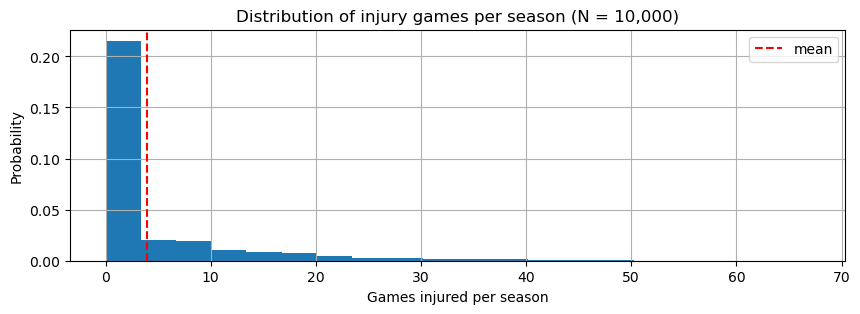

In [6]:
# Histogram of total injured games per season
plt.figure(figsize=(10,3))
plt.hist(total_injured, bins=20, density=True)
plt.grid(True)
plt.xlabel('Games injured per season')
plt.ylabel('Probability')
plt.axvline(np.mean(total_injured), color='red', linestyle='dashed', label='mean')
plt.legend()
plt.title('Distribution of injury games per season (N = 10,000)')
plt.show()

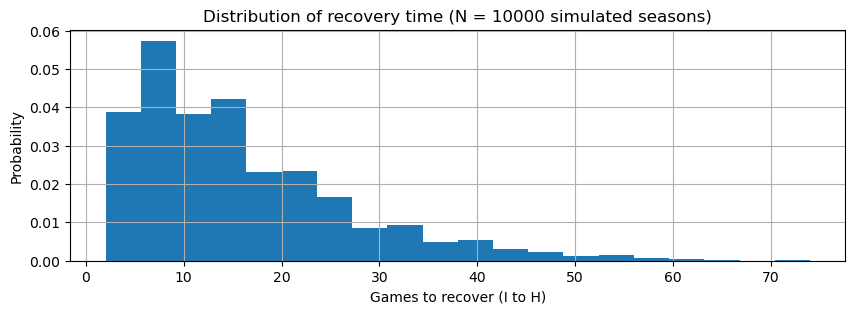

Recovery observations: 3277


In [11]:
# Histogram of recovery times (number of games in I before moving to H)
plt.figure(figsize=(10,3))
plt.hist(recovery_times, bins=20, density=True)
plt.grid(True)
plt.xlabel('Games to recover (I to H)')
plt.ylabel('Probability')
plt.title('Distribution of recovery time (N = 10000 simulated seasons)')
plt.show()

print(f"Recovery observations: {len(recovery_times)}")

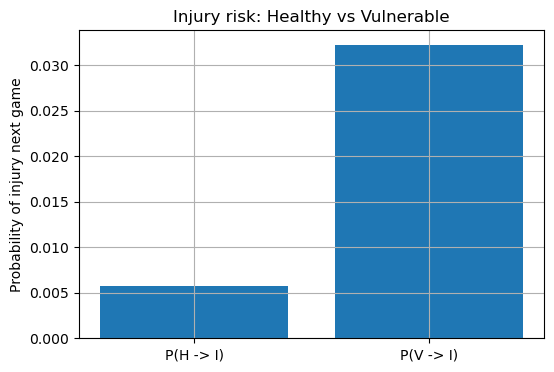

In [8]:
# Bar chart comparing injury rates starting from H vs V
plt.figure(figsize=(6,4))
labels = ['P(H -> I)', 'P(V -> I)']
values = [P[0, 2], P[1, 2]]
plt.bar(labels, values)
plt.grid(True)
plt.ylabel('Probability of injury next game')
plt.title('Injury risk: Healthy vs Vulnerable')
plt.show()